In [46]:
import pandas as pd
import json

In [47]:
df=pd.read_csv('netflix_titles.csv')

In [48]:
# Gather basic insights
info={
    "shape": df.shape,
    "columns": list(df.columns),
    "missing_values": df.isnull().sum().to_dict(),
    "dtypes": df.dtypes.astype(str).to_dict()
}
print(json.dumps(info, indent=2))
print("\n--- First 5 rows ---")
print(df.head(5).to_string())

{
  "shape": [
    8807,
    12
  ],
  "columns": [
    "show_id",
    "type",
    "title",
    "director",
    "cast",
    "country",
    "date_added",
    "release_year",
    "rating",
    "duration",
    "listed_in",
    "description"
  ],
  "missing_values": {
    "show_id": 0,
    "type": 0,
    "title": 0,
    "director": 2634,
    "cast": 825,
    "country": 831,
    "date_added": 10,
    "release_year": 0,
    "rating": 4,
    "duration": 3,
    "listed_in": 0,
    "description": 0
  },
  "dtypes": {
    "show_id": "str",
    "type": "str",
    "title": "str",
    "director": "str",
    "cast": "str",
    "country": "str",
    "date_added": "str",
    "release_year": "int64",
    "rating": "str",
    "duration": "str",
    "listed_in": "str",
    "description": "str"
  }
}

--- First 5 rows ---
  show_id     type                  title         director                                                                                                                                

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Term Frequency – Inverse Document Frequency

In [50]:
df=df.drop(columns=['show_id', 'date_added'])
print(df.head(5).to_string())

      type                  title         director                                                                                                                                                                                                                                                                                                             cast        country  release_year rating   duration                                                      listed_in                                                                                                                                               description
0    Movie   Dick Johnson Is Dead  Kirsten Johnson                                                                                                                                                                                                                                                                                                              NaN  United States          

In [51]:
features_to_fill=['director', 'cast', 'country', 'listed_in', 'description']
for feature in features_to_fill:
    df[feature] = df[feature].fillna('')
print(df[features_to_fill].head(5).to_string())

          director                                                                                                                                                                                                                                                                                                             cast        country                                                      listed_in                                                                                                                                               description
0  Kirsten Johnson                                                                                                                                                                                                                                                                                                                   United States                                                  Documentaries  As her father nears the end of his life, 

In [52]:
def create_weighted_text(row):
    director_weight=(row['director'] +' ')*3

    cast_weight=(row['cast'] +' ')*2
    genre_weight=(row['listed_in'] +' ')*2

    discription_weight=row['description']

    return director_weight + cast_weight + genre_weight + discription_weight

df['weighted_text']=df.apply(create_weighted_text, axis=1)

print(df[['weighted_text']].head(5).to_string())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            weighted_text
0                                                                                                                                             

In [53]:
tfidf = TfidfVectorizer(stop_words='english')

In [54]:
tfidf_matrix = tfidf.fit_transform(df['weighted_text'])

In [55]:
print("Shape of our TF-IDF Matrix:", tfidf_matrix.shape)

Shape of our TF-IDF Matrix: (8807, 49941)


In [56]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

print("Starting the K-Means experiment. This might take a couple of minutes...")

Starting the K-Means experiment. This might take a couple of minutes...


In [57]:
k_values = range(5, 45, 5)
inertia_scores = []

In [58]:
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    kmeans.fit(tfidf_matrix)

    inertia_scores.append(kmeans.inertia_)
    print(f"Tested K={k} | Inertia Score: {kmeans.inertia_:.0f}")    

Tested K=5 | Inertia Score: 8575
Tested K=10 | Inertia Score: 8494
Tested K=15 | Inertia Score: 8447
Tested K=20 | Inertia Score: 8412
Tested K=25 | Inertia Score: 8375
Tested K=30 | Inertia Score: 8344
Tested K=35 | Inertia Score: 8337
Tested K=40 | Inertia Score: 8307


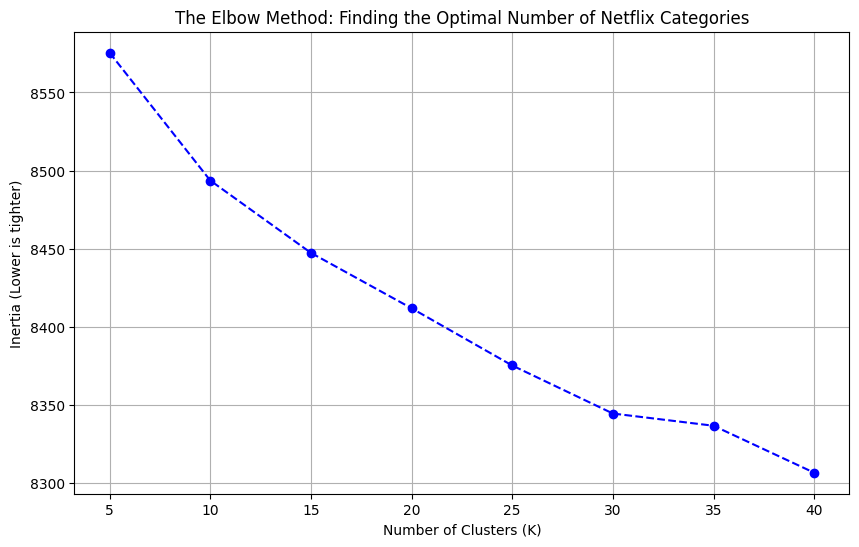

In [59]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia_scores, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method: Finding the Optimal Number of Netflix Categories')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Lower is tighter)')
plt.grid(True)
plt.show()

In [60]:
final_k = 15
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)

print("Assigning movies to their new clusters...")
df['cluster'] = kmeans_final.fit_predict(tfidf_matrix)

Assigning movies to their new clusters...


In [61]:
def inspect_cluster(cluster_number, num_movies=5):
    print(f"\n--- PEEKING INTO CLUSTER {cluster_number} ---")

    cluster_movies = df[df['cluster'] == cluster_number]

    sample = cluster_movies[['title', 'listed_in', 'description']].sample(min(num_movies, len(cluster_movies)), random_state=42)
    
    for index, row in sample.iterrows():
        print(f"🎬 {row['title']}")
        print(f"   Genres: {row['listed_in']}")
        print(f"   Plot: {row['description'][:100]}...\n")

inspect_cluster(0)
inspect_cluster(3)
inspect_cluster(7)


--- PEEKING INTO CLUSTER 0 ---
🎬 Hannah Gadsby: Nanette
   Genres: Stand-Up Comedy
   Plot: Australian comic Hannah Gadsby reshapes standard stand-up by pairing punchlines with personal revela...

🎬 Dr Jason Leong Hashtag Blessed
   Genres: Stand-Up Comedy
   Plot: In this stand-up special, former doctor Jason Leong gives his diagnoses on the nonsense of tradition...

🎬 Brian Regan: On the Rocks
   Genres: Stand-Up Comedy
   Plot: Brian Regan tackles the big issues weighing on him, including aging, time, obsessive behavior, backp...

🎬 Jandino: Whatever it Takes
   Genres: Stand-Up Comedy
   Plot: Jandino Asporaat riffs on the challenges of raising kids and serenades the audience with a rousing r...

🎬 Maurício Meirelles: Generating Chaos
   Genres: Stand-Up Comedy
   Plot: Comedian Maurício Meirelles explores his chaotic mind with scathingly funny views on family, prejudi...


--- PEEKING INTO CLUSTER 3 ---
🎬 Born Racer
   Genres: Documentaries, Sports Movies
   Plot: In this all-acc

In [62]:
from sklearn.metrics.pairwise import cosine_similarity

print("\nCalculating cosine similarity angle between all 8,807 movies...")


Calculating cosine similarity angle between all 8,807 movies...


In [63]:
cosine_sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [64]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

In [65]:
def get_recommendations(title, cosine_sim=cosine_sim_matrix):
    if title not in indices:
        return f"Sorry, '{title}' is not in our database."
    
    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    top_5_movies = sim_scores[1:6]

    movie_indices = [i[0] for i in top_5_movies]

    print(f"\n--- IF YOU LIKED '{title}', YOU MIGHT LIKE: ---")
    return df[['title', 'listed_in', 'cluster']].iloc[movie_indices]

print(get_recommendations("Stranger Things"))
print(get_recommendations("Sisyphus"))


--- IF YOU LIKED 'Stranger Things', YOU MIGHT LIKE: ---
                                                  title  \
5200                             Beyond Stranger Things   
1127                                   Prank Encounters   
2190                               The Umbrella Academy   
3707                                       Motown Magic   
1195  Operation Varsity Blues: The College Admission...   

                                              listed_in  cluster  
5200  Stand-Up Comedy & Talk Shows, TV Mysteries, TV...       10  
1127                 Reality TV, TV Comedies, TV Horror       13  
2190  TV Action & Adventure, TV Mysteries, TV Sci-Fi...       10  
3707                      Kids' TV, TV Sci-Fi & Fantasy       10  
1195                                      Documentaries        3  

--- IF YOU LIKED 'Sisyphus', YOU MIGHT LIKE: ---
           title                                          listed_in  cluster
3613  Reply 1994  International TV Shows, Korean TV Shows, 

In [66]:
import pickle
print("Training complete! Saving the brain to disk...")

Training complete! Saving the brain to disk...


In [67]:
model_payload = {
    'indices_map': indices,
    'similarity_matrix': cosine_sim_matrix,
    'catalog_df': df[['title', 'listed_in', 'cluster']]
}

In [68]:
with open('recommender.pkl', 'wb') as file:
    pickle.dump(model_payload, file)

print("Model successfully pickled! You can now close this script.")

Model successfully pickled! You can now close this script.


In [69]:
import pickle
import time

print("Booting up the Netflix Engine...")
start_time = time.time()

Booting up the Netflix Engine...


In [70]:
with open('recommender.pkl', 'rb') as file:
    saved_model = pickle.load(file)

In [71]:
indices = saved_model['indices_map']
cosine_sim = saved_model['similarity_matrix']
df = saved_model['catalog_df']

print(f"Engine ready in {time.time() - start_time:.2f} seconds!")

Engine ready in 10.37 seconds!


In [72]:
def get_fast_recommendations(title):
    if title not in indices:
        return f"Sorry, '{title}' is not in our database."
    
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    top_5_movies = sim_scores[1:6]
    movie_indices = [i[0] for i in top_5_movies]
    
    print(f"\n--- IF YOU LIKED '{title}', YOU MIGHT LIKE: ---")
    return df.iloc[movie_indices]

In [73]:
print(get_fast_recommendations("Stranger Things"))


--- IF YOU LIKED 'Stranger Things', YOU MIGHT LIKE: ---
                                                  title  \
5200                             Beyond Stranger Things   
1127                                   Prank Encounters   
2190                               The Umbrella Academy   
3707                                       Motown Magic   
1195  Operation Varsity Blues: The College Admission...   

                                              listed_in  cluster  
5200  Stand-Up Comedy & Talk Shows, TV Mysteries, TV...       10  
1127                 Reality TV, TV Comedies, TV Horror       13  
2190  TV Action & Adventure, TV Mysteries, TV Sci-Fi...       10  
3707                      Kids' TV, TV Sci-Fi & Fantasy       10  
1195                                      Documentaries        3  
